In [5]:
# Import core data processing and visualization libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("📍 Python Version Engine Running:", sys.version)
print("🔄 Global Data Science environment verified and ready!")

📍 Python Version Engine Running: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
🔄 Global Data Science environment verified and ready!


In [6]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [11]:
# Define path pointing into your local subfolder
data_dir = "data"

# Read the relational CSV files and convert '\N' strings to actual NaN null values
results = pd.read_csv(os.path.join(data_dir, 'results.csv'), na_values=r'\N')
races = pd.read_csv(os.path.join(data_dir, 'races.csv'), na_values=r'\N')
drivers = pd.read_csv(os.path.join(data_dir, 'drivers.csv'), na_values=r'\N')
constructors = pd.read_csv(os.path.join(data_dir, 'constructors.csv'), na_values=r'\N')

# Merge data fields together
df = results.merge(races, on='raceId', suffixes=('_results', '_races'))
df = df.merge(drivers, on='driverId')
df = df.merge(constructors, on='constructorId')

print(f"✅ Master dataset compiled. Pre-cleaned row count: {df.shape[0]}")
df.head(3)

✅ Master dataset compiled. Pre-cleaned row count: 27524


,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,code,forename,surname,dob,nationality_x,url_y,constructorRef,name_y,nationality_y,url
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,...,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,...,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,...,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...


In [12]:

# Read the relational CSV files and convert '\N' strings to actual NaN null values
results = pd.read_csv(os.path.join(data_dir, 'results.csv'), na_values=r'\N')
races = pd.read_csv(os.path.join(data_dir, 'races.csv'), na_values=r'\N')
drivers = pd.read_csv(os.path.join(data_dir, 'drivers.csv'), na_values=r'\N')
constructors = pd.read_csv(os.path.join(data_dir, 'constructors.csv'), na_values=r'\N')

# Merge data fields together
df = results.merge(races, on='raceId', suffixes=('_results', '_races'))
df = df.merge(drivers, on='driverId')
df = df.merge(constructors, on='constructorId')

print(f"✅ Master dataset compiled. Pre-cleaned row count: {df.shape[0]}")
df.head(3)

✅ Master dataset compiled. Pre-cleaned row count: 27524


,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,code,forename,surname,dob,nationality_x,url_y,constructorRef,name_y,nationality_y,url
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,...,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,...,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,...,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...


In [13]:
# Drop rows where critical values are empty or invalid
df = df.dropna(subset=['positionOrder', 'grid', 'year', 'round'])

# Ensure numeric columns are forced to proper number data types
df['grid'] = pd.to_numeric(df['grid'])
df['year'] = pd.to_numeric(df['year'])
df['round'] = pd.to_numeric(df['round'])
df['positionOrder'] = pd.to_numeric(df['positionOrder'])

# Set features according to project rules
numerical_features = ['year', 'round', 'grid']
categorical_features = ['circuitId', 'driverRef', 'constructorRef']

X = df[numerical_features + categorical_features]
y = df['positionOrder']

# Set random split state anchor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"🧹 Cleaned data separation completed successfully!")
print(f"Training rows: {len(X_train)} | Test verification rows: {len(X_test)}")

🧹 Cleaned data separation completed successfully!
Training rows: 21985 | Test verification rows: 5497


In [14]:
# Standardize numeric distributions and parse category tags
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("⚙️ Data preprocessing pipeline built successfully on global thread.")

⚙️ Data preprocessing pipeline built successfully on global thread.


In [15]:
# Evaluate the 3 performance configurations sequentially
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

trained_pipelines = {}
print("🚀 Training processing pipelines (this may take a minute)...")

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    
    preds = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"\n=== {name} ===")
    print(f"• Mean Absolute Error (MAE): {mae:.2f} positions")
    print(f"• Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"• R² Score (Variance Explained): {r2:.2f}")

🚀 Training processing pipelines (this may take a minute)...

=== Linear Regression ===
• Mean Absolute Error (MAE): 5.38 positions
• Root Mean Squared Error (RMSE): 6.56
• R² Score (Variance Explained): 0.27

=== Random Forest Regressor ===
• Mean Absolute Error (MAE): 4.86 positions
• Root Mean Squared Error (RMSE): 6.15
• R² Score (Variance Explained): 0.36

=== Gradient Boosting Regressor ===
• Mean Absolute Error (MAE): 4.85 positions
• Root Mean Squared Error (RMSE): 5.91
• R² Score (Variance Explained): 0.41


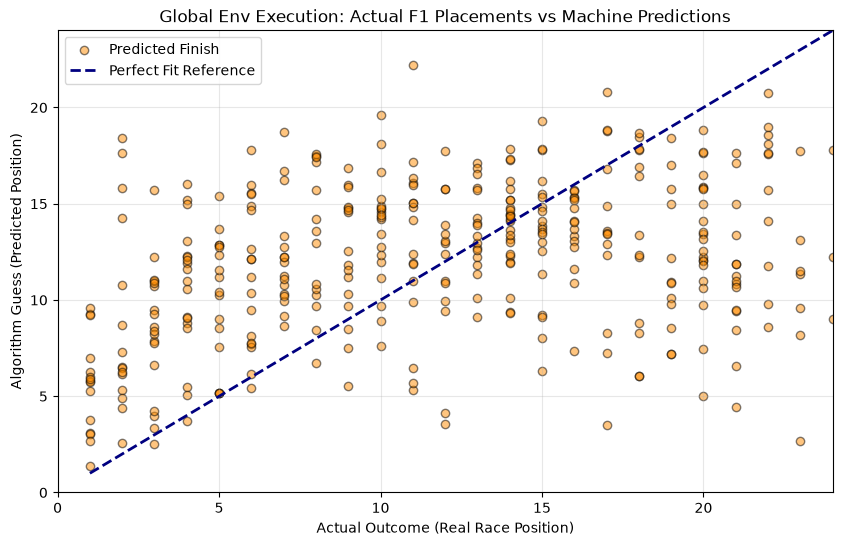

In [16]:
# Draw distribution metrics using predictions from Random Forest
rf_preds = trained_pipelines["Random Forest Regressor"].predict(X_test)

plt.figure(figsize=(10, 6))
# Sample 400 random points for a clean visual scatter comparison
sample_idx = np.random.choice(len(y_test), size=400, replace=False)

plt.scatter(y_test.iloc[sample_idx], rf_preds[sample_idx], 
            alpha=0.5, color='darkorange', edgecolors='k', label='Predicted Finish')
plt.plot([1, 24], [1, 24], color='navy', linestyle='--', linewidth=2, label='Perfect Fit Reference')

plt.title('Global Env Execution: Actual F1 Placements vs Machine Predictions')
plt.xlabel('Actual Outcome (Real Race Position)')
plt.ylabel('Algorithm Guess (Predicted Position)')
plt.xlim(0, 24)
plt.ylim(0, 24)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# ==========================================
# 7. CHOOSE F1 LIVE PREDICTION
# ==========================================
def predict_f1_race(year, round_num, grid_position, track_id, driver_name, team_name):
    # Format the input values into a small temporary DataFrame
    custom_input = pd.DataFrame([{
        'year': year,
        'round': round_num,
        'grid': grid_position,
        'circuitId': track_id,
        'driverRef': driver_name,
        'constructorRef': team_name
    }])
    
    # Use your best-performing Gradient Boosting model to guess the finish
    best_model = trained_pipelines["Gradient Boosting Regressor"]
    prediction = best_model.predict(custom_input)[0]
    
    print(f"🏎️ Prediction Summary:")
    print(f"• Driver: {driver_name.title()} | Team: {team_name.title()}")
    print(f"• Track ID: {track_id} | Starting Position: Grid {grid_position}")
    print(f"🔮 Estimated Final Race Finishing Position: P{round(prediction)}")

# Run a test prediction example:
# Predict where Lewis Hamilton (hamilton) starting P5 in Mercedes (mercedes) finishes at Albert Park (1)
predict_f1_race(
    year=2024, 
    round_num=1, 
    grid_position=5, 
    track_id=1, 
    driver_name='hamilton', 
    team_name='mercedes'
)

🏎️ Prediction Summary:
• Driver: Hamilton | Team: Mercedes
• Track ID: 1 | Starting Position: Grid 5
🔮 Estimated Final Race Finishing Position: P6
